## Data Loading and Initial Exploration

In [2]:
# Import necessary libraries
import pandas as pd
from google.colab import files
import io

### Upload the `steam.csv` file

In [3]:
# 1. Use google.colab's files.upload() to let you upload the CSV file
uploaded = files.upload()

# Assuming the file is named 'steam.csv'
file_name = 'steam.csv'

if file_name in uploaded:
    # 2. Loads the CSV into a pandas DataFrame called `df`
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print(f"'{file_name}' uploaded and loaded into DataFrame 'df'.")
else:
    print(f"Error: '{file_name}' not found in uploaded files. Please ensure you upload the correct file.")

Saving steam.csv to steam.csv
'steam.csv' uploaded and loaded into DataFrame 'df'.


### Initial Data Inspection

In [4]:
if 'df' in locals():
    # 3. Prints the shape of the dataframe (rows, columns)
    print("\nShape of the DataFrame:", df.shape)

    # 4. Prints all column names as a list
    print("\nColumn Names:", df.columns.tolist())

    # 5. Displays the first 5 rows using df.head()
    print("\nFirst 5 rows of the DataFrame:")
    display(df.head())

    # 6. Runs df.info() to show data types
    print("\nDataFrame Info:")
    df.info()

    # 7. Runs df.isnull().sum() to show missing values per column
    print("\nMissing values per column:")
    display(df.isnull().sum())
else:
    print("DataFrame 'df' not created. Please ensure the CSV file was uploaded successfully.")


Shape of the DataFrame: (27075, 18)

Column Names: ['appid', 'name', 'release_date', 'english', 'developer', 'publisher', 'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags', 'achievements', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime', 'owners', 'price']

First 5 rows of the DataFrame:


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075

,0
appid,0
name,0
release_date,0
english,0
developer,1
publisher,14
platforms,0
required_age,0
categories,0
genres,0


### Data Cleaning and Feature Engineering

In [5]:
# 1. Fills missing values in 'developer' and 'publisher' with the string 'Unknown'
df['developer'] = df['developer'].fillna('Unknown')
df['publisher'] = df['publisher'].fillna('Unknown')

In [6]:
# 2. Converts 'release_date' to proper datetime format
df['release_date'] = pd.to_datetime(df['release_date'])

In [7]:
# 3. Creates a new column 'release_year' by extracting the year from 'release_date'
df['release_year'] = df['release_date'].dt.year

In [8]:
# 4. Creates a new numeric column 'owners_midpoint'
# This function takes an owner string and returns the midpoint
def calculate_owners_midpoint(owners_range):
    try:
        lower, upper = map(int, owners_range.split('-'))
        return (lower + upper) / 2
    except ValueError:
        return None  # Handle cases where the format might be unexpected

df['owners_midpoint'] = df['owners'].apply(calculate_owners_midpoint)

In [9]:
print("\n--- Cleaning Summary ---")
# 5. Prints the final shape and confirms no missing values remain in 'developer' and 'publisher'
print("Final DataFrame Shape:", df.shape)
print("Missing values in 'developer' after cleaning:", df['developer'].isnull().sum())
print("Missing values in 'publisher' after cleaning:", df['publisher'].isnull().sum())


--- Cleaning Summary ---
Final DataFrame Shape: (27075, 20)
Missing values in 'developer' after cleaning: 0
Missing values in 'publisher' after cleaning: 0


In [10]:
# 6. Displays the first 5 rows to confirm the new columns look correct
print("\nFirst 5 rows of the cleaned DataFrame:")
display(df.head())


First 5 rows of the cleaned DataFrame:


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price,release_year,owners_midpoint
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19,2000,15000000.0
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99,1999,7500000.0
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99,2003,7500000.0
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99,2001,7500000.0
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99,1999,7500000.0


### Feature Engineering: Creating New Metrics

In [11]:
# 1. 'total_ratings' — sum of 'positive_ratings' and 'negative_ratings'
df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']

In [12]:
# 2. 'satisfaction_pct' — positive_ratings divided by total_ratings, multiplied by 100, rounded to 2 decimal places.
# For rows where total_ratings is 0, set this to NaN (to avoid division by zero)
df['satisfaction_pct'] = (df['positive_ratings'] / df['total_ratings'] * 100).round(2)
df.loc[df['total_ratings'] == 0, 'satisfaction_pct'] = pd.NA

In [13]:
# 3. 'is_free' — a boolean column that is True if 'price' equals 0, False otherwise
df['is_free'] = (df['price'] == 0)

In [14]:
# 4. 'price_category' — a categorical column that buckets 'price' into:
# 'Free' (price=0), 'Budget' (0 < price <= 5), 'Mid-range' (5 < price <= 15),
# 'Premium' (15 < price <= 30), 'AAA' (price > 30)
def categorize_price(price):
    if price == 0:
        return 'Free'
    elif 0 < price <= 5:
        return 'Budget'
    elif 5 < price <= 15:
        return 'Mid-range'
    elif 15 < price <= 30:
        return 'Premium'
    else:
        return 'AAA'

df['price_category'] = df['price'].apply(categorize_price)

In [15]:
# 5. 'primary_genre' — extract just the FIRST genre from the 'genres' column
df['primary_genre'] = df['genres'].apply(lambda x: x.split(';')[0] if pd.notna(x) else None)

In [16]:
print("\n--- New Column Summaries ---")
# Print the value counts for 'price_category'
print("\nValue counts for 'price_category':")
display(df['price_category'].value_counts())

# Print the value counts for 'primary_genre' (top 10)
print("\nTop 10 value counts for 'primary_genre':")
display(df['primary_genre'].value_counts().head(10))


--- New Column Summaries ---

Value counts for 'price_category':


,count
price_category,
Budget,13293
Mid-range,9246
Free,2560
Premium,1653
AAA,323



Top 10 value counts for 'primary_genre':


,count
primary_genre,
Action,11212
Adventure,5256
Casual,4373
Indie,2623
Violent,709
Simulation,631
Strategy,532
RPG,407
Free to Play,395


In [17]:
# Display the first 5 rows showing all the new columns
print("\nFirst 5 rows of DataFrame with new features:")
display(df.head())


First 5 rows of DataFrame with new features:


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,...,median_playtime,owners,price,release_year,owners_midpoint,total_ratings,satisfaction_pct,is_free,price_category,primary_genre
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,317,10000000-20000000,7.19,2000,15000000.0,127873,97.39,False,Mid-range,Action
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,62,5000000-10000000,3.99,1999,7500000.0,3951,83.98,False,Budget,Action
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,...,34,5000000-10000000,3.99,2003,7500000.0,3814,89.56,False,Budget,Action
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,184,5000000-10000000,3.99,2001,7500000.0,1540,82.66,False,Budget,Action
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,...,415,5000000-10000000,3.99,1999,7500000.0,5538,94.80,False,Budget,Action


### Data Visualization

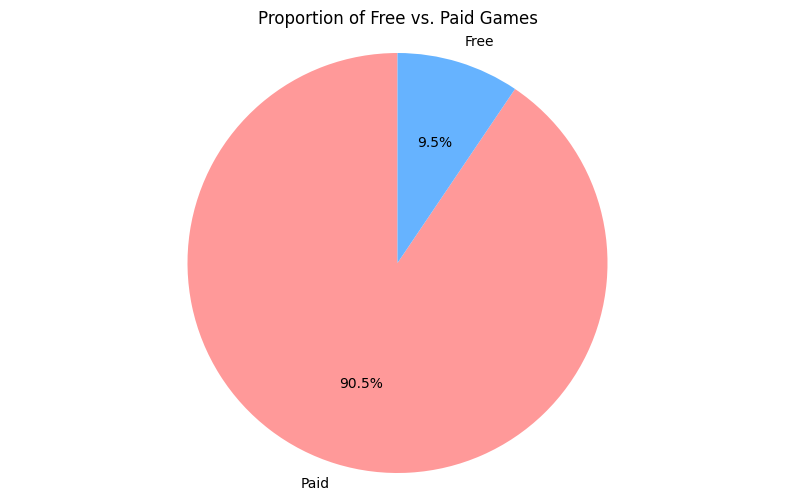

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pie chart showing the proportion of Free vs Paid games
plt.figure(figsize=(10, 6))
free_paid_counts = df['is_free'].value_counts()
plt.pie(free_paid_counts, labels=['Paid' if label == False else 'Free' for label in free_paid_counts.index], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Proportion of Free vs. Paid Games')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

/tmp/ipykernel_1414/2201934334.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='price_category', order=['Free', 'Budget', 'Mid-range', 'Premium', 'AAA'], palette='viridis')


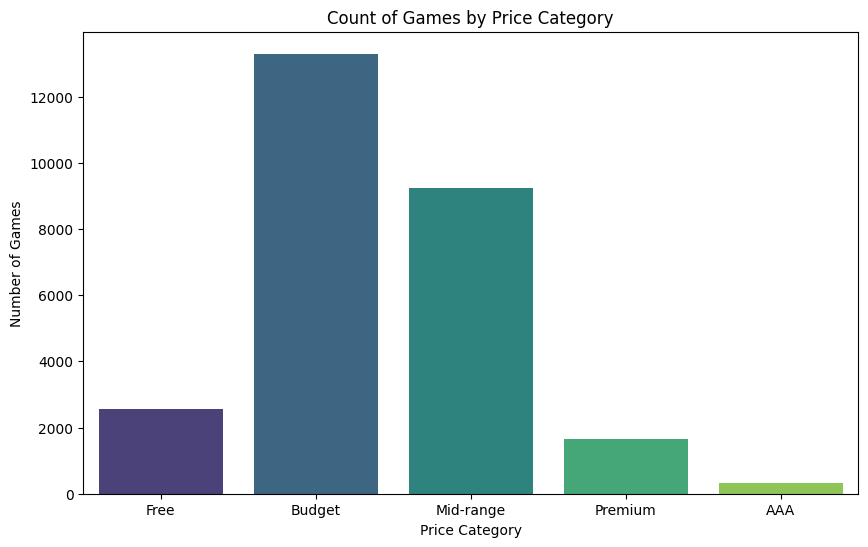

In [19]:
# 2. Bar chart showing the count of games in each 'price_category'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='price_category', order=['Free', 'Budget', 'Mid-range', 'Premium', 'AAA'], palette='viridis')
plt.title('Count of Games by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Number of Games')
plt.show()

/tmp/ipykernel_1414/599692322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='price_category', y='satisfaction_pct', order=['Free', 'Budget', 'Mid-range', 'Premium', 'AAA'], palette='coolwarm', showfliers=False) # showfliers=False to hide outliers for better readability


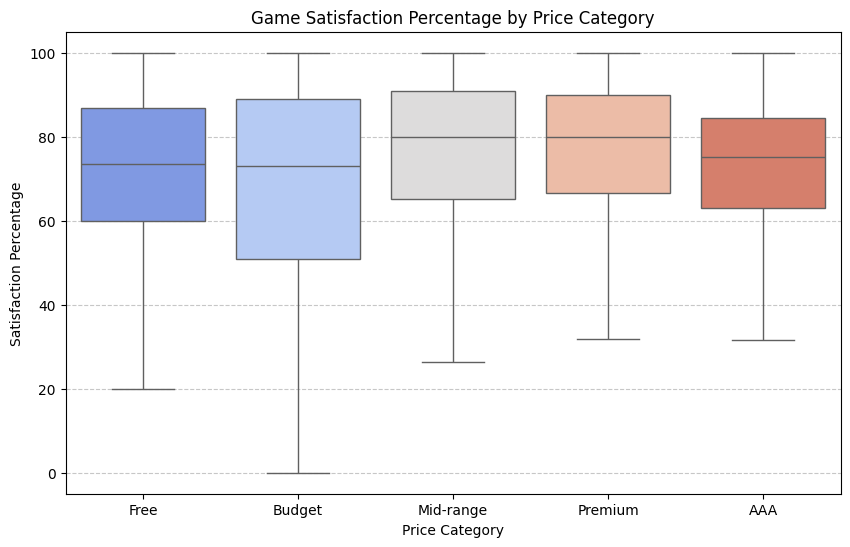

In [20]:
# 3. Box plot comparing 'satisfaction_pct' across different 'price_category' groups
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='price_category', y='satisfaction_pct', order=['Free', 'Budget', 'Mid-range', 'Premium', 'AAA'], palette='coolwarm', showfliers=False) # showfliers=False to hide outliers for better readability
plt.title('Game Satisfaction Percentage by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Satisfaction Percentage')
plt.ylim(-5, 105) # Set y-axis limits to represent percentage
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

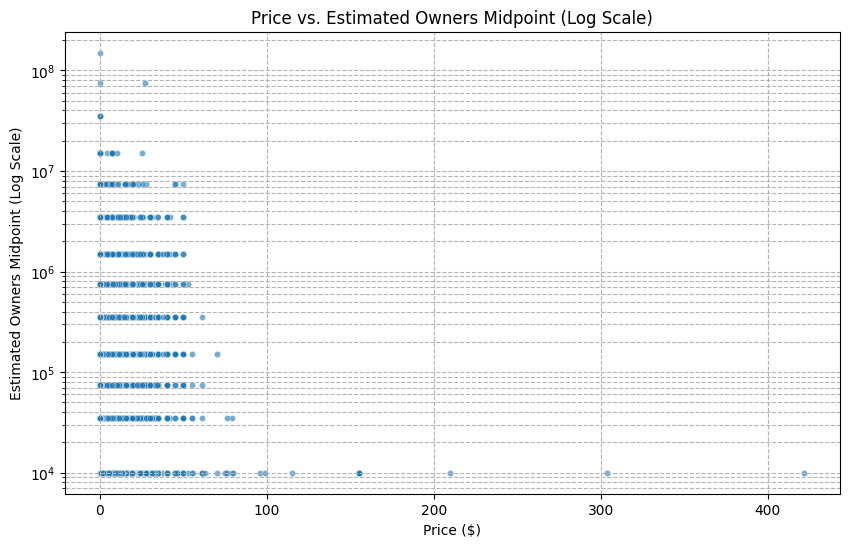

In [21]:
# 4. Scatter plot of 'price' (x-axis) vs 'owners_midpoint' (y-axis) with a log scale on the y-axis
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='owners_midpoint', alpha=0.6, s=20) # s controls marker size
plt.yscale('log') # Set y-axis to log scale
plt.title('Price vs. Estimated Owners Midpoint (Log Scale)')
plt.xlabel('Price ($)')
plt.ylabel('Estimated Owners Midpoint (Log Scale)')
plt.grid(True, which="both", ls="--", c='0.7') # Add grid for log scale
plt.show()

### Genre Analysis

/tmp/ipykernel_1414/1387446754.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='Blues_d')


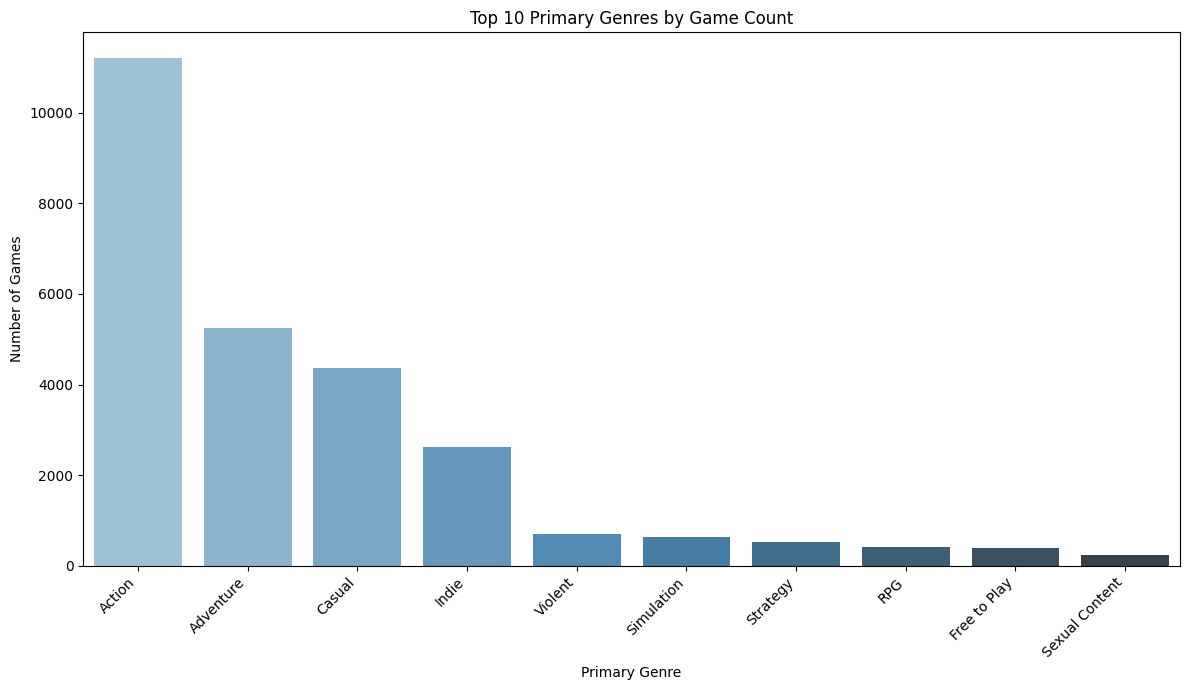

In [22]:
# 1. Bar chart showing the TOP 10 'primary_genre' values by count
plt.figure(figsize=(12, 7))
genre_counts = df['primary_genre'].value_counts().head(10)
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='Blues_d')
plt.title('Top 10 Primary Genres by Game Count')
plt.xlabel('Primary Genre')
plt.ylabel('Number of Games')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1414/2305758659.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_playtime_by_genre.index, y=avg_playtime_by_genre.values, palette='Greens_d')


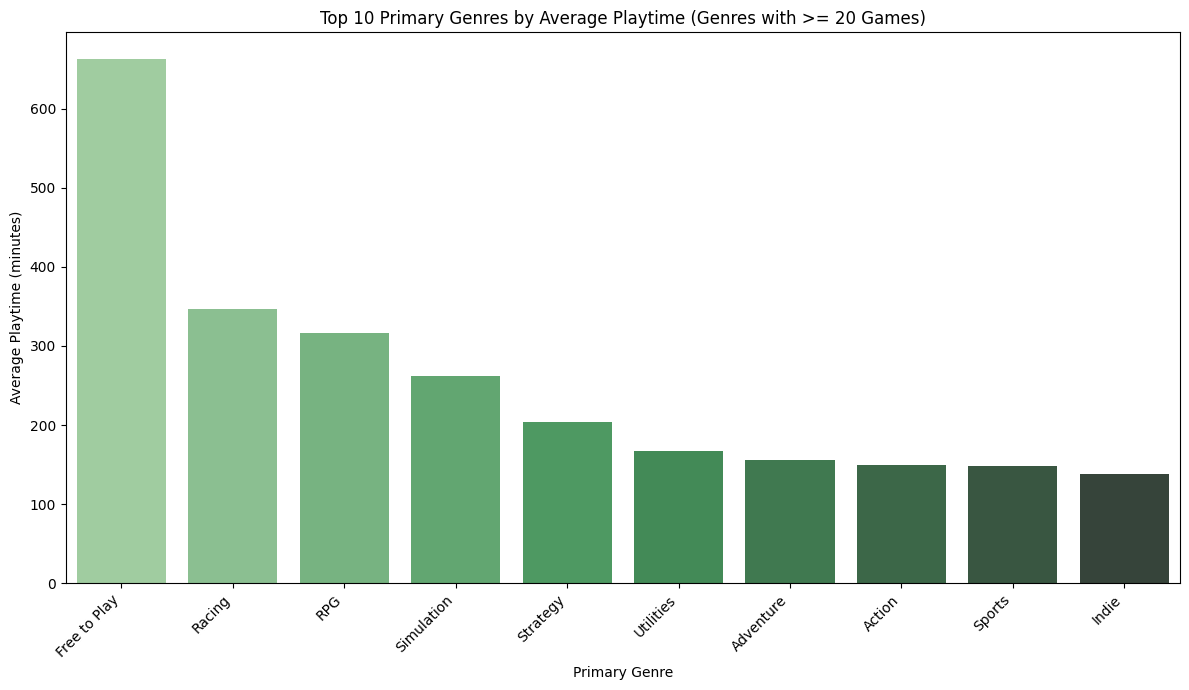

In [23]:
# Calculate genre counts to filter for genres with at least 20 games
genre_game_counts = df['primary_genre'].value_counts()
valid_genres = genre_game_counts[genre_game_counts >= 20].index

df_filtered_genres = df[df['primary_genre'].isin(valid_genres)]

# 2. Bar chart showing the TOP 10 genres by average 'average_playtime'
plt.figure(figsize=(12, 7))
avg_playtime_by_genre = df_filtered_genres.groupby('primary_genre')['average_playtime'].mean().nlargest(10)
sns.barplot(x=avg_playtime_by_genre.index, y=avg_playtime_by_genre.values, palette='Greens_d')
plt.title('Top 10 Primary Genres by Average Playtime (Genres with >= 20 Games)')
plt.xlabel('Primary Genre')
plt.ylabel('Average Playtime (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1414/2834986384.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_satisfaction_by_genre.index, y=avg_satisfaction_by_genre.values, palette='Reds_d')


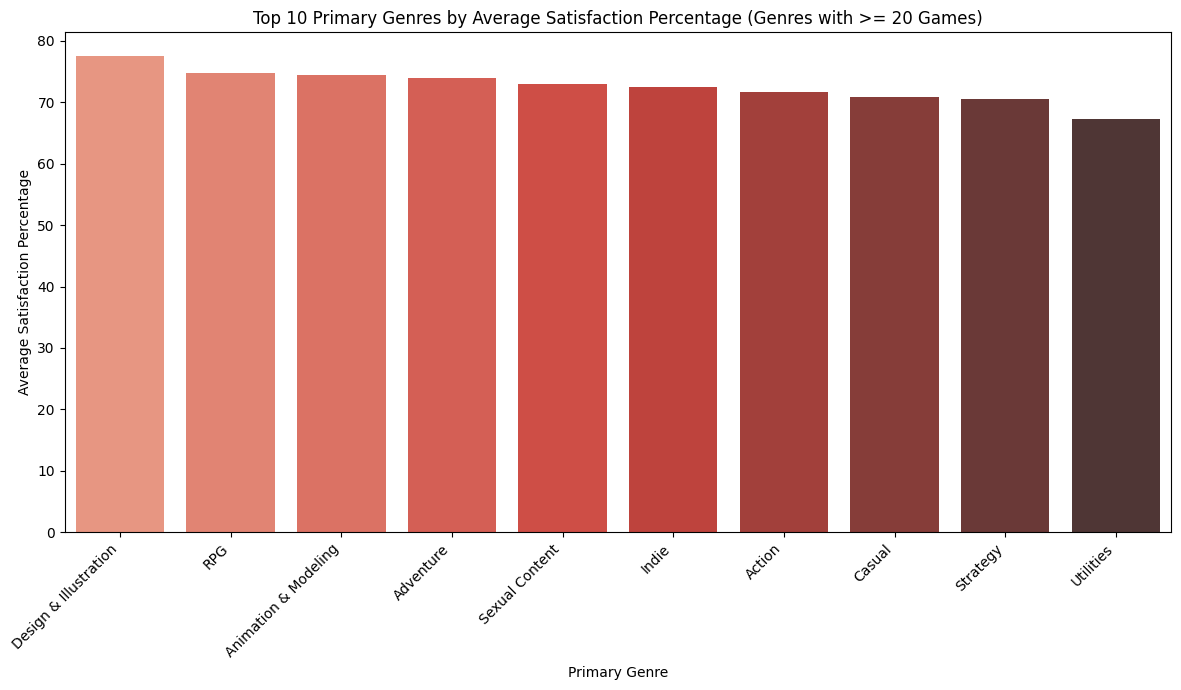

In [24]:
# 3. Bar chart showing the TOP 10 genres by average 'satisfaction_pct'
plt.figure(figsize=(12, 7))
avg_satisfaction_by_genre = df_filtered_genres.groupby('primary_genre')['satisfaction_pct'].mean().nlargest(10)
sns.barplot(x=avg_satisfaction_by_genre.index, y=avg_satisfaction_by_genre.values, palette='Reds_d')
plt.title('Top 10 Primary Genres by Average Satisfaction Percentage (Genres with >= 20 Games)')
plt.xlabel('Primary Genre')
plt.ylabel('Average Satisfaction Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
# 4. Prints a short summary table combining genre, game count, avg playtime, and avg satisfaction
# For the top 10 genres by game count

# Get top 10 genres by count again
top_10_genres_by_count = df['primary_genre'].value_counts().head(10).index

# Filter DataFrame to include only these top 10 genres
df_top_10_genres = df[df['primary_genre'].isin(top_10_genres_by_count)].copy()

# Calculate metrics for these genres
summary_table = df_top_10_genres.groupby('primary_genre').agg(
    game_count=('name', 'count'),
    avg_playtime=('average_playtime', 'mean'),
    avg_satisfaction=('satisfaction_pct', 'mean')
).round(2)

# Sort the summary table by game count to align with the first bar chart
summary_table = summary_table.sort_values(by='game_count', ascending=False)

print("\nSummary Table for Top 10 Genres by Game Count:")
display(summary_table)


Summary Table for Top 10 Genres by Game Count:


,game_count,avg_playtime,avg_satisfaction
primary_genre,,,
Action,11212,149.87,71.61
Adventure,5256,155.52,73.99
Casual,4373,72.93,70.92
Indie,2623,137.75,72.41
Violent,709,41.52,62.15
Simulation,631,261.65,63.51
Strategy,532,204.23,70.47
RPG,407,316.54,74.79
Free to Play,395,663.20,67.13


### Game Ratings Analysis

In [26]:
# 1. Filters to only games with at least 1000 total_ratings
#    then shows the TOP 15 highest 'satisfaction_pct' games as a table

print("\n--- Top 15 Games by Satisfaction (with at least 1000 total ratings) ---")
high_satisfaction_games = df[df['total_ratings'] >= 1000].sort_values(
    by='satisfaction_pct', ascending=False
).head(15)
display(high_satisfaction_games[['name', 'total_ratings', 'satisfaction_pct']])


--- Top 15 Games by Satisfaction (with at least 1000 total ratings) ---


,name,total_ratings,satisfaction_pct
18404,東方天空璋 ～ Hidden Star in Four Seasons.,4167,98.73
23,Portal 2,140111,98.65
7577,Factorio,48641,98.51
7130,TY the Tasmanian Tiger,1702,98.47
7755,Epic Battle Fantasy 5,1092,98.26
2290,One Finger Death Punch,14437,98.23
4344,Finding Paradise,6701,98.16
23649,NEKOPARA Extra,1556,98.14
18113,Baba Is You,1326,98.04
7399,OneShot,11205,98.04


In [27]:
# 2. Shows the TOP 15 games by raw 'total_ratings' count (most-reviewed games overall)
print("\n--- Top 15 Games by Total Ratings (Most-Reviewed) ---")
top_total_ratings_games = df.sort_values(by='total_ratings', ascending=False).head(15)
display(top_total_ratings_games[['name', 'total_ratings', 'satisfaction_pct']])


--- Top 15 Games by Total Ratings (Most-Reviewed) ---


,name,total_ratings,satisfaction_pct
25,Counter-Strike: Global Offensive,3046717,86.80
22,Dota 2,1005586,85.87
12836,PLAYERUNKNOWN'S BATTLEGROUNDS,983260,50.46
19,Team Fortress 2,549915,93.81
2478,Grand Theft Auto V,468369,70.26
121,Garry's Mod,380154,95.68
1467,PAYDAY 2,365180,84.52
3362,Unturned,324056,90.29
5235,Tom Clancy's Rainbow Six® Siege,310798,80.82
2016,Rust,274079,80.40


In [28]:
# 3. Identifies the TOP 10 "most controversial" games
#    (at least 5000 total_ratings AND satisfaction_pct between 40 and 60)

print("\n--- Top 10 Most Controversial Games ---")
controversial_games = df[
    (df['total_ratings'] >= 5000) &
    (df['satisfaction_pct'] >= 40) &
    (df['satisfaction_pct'] <= 60)
].sort_values(by='total_ratings', ascending=False).head(10) # Sort by total ratings to show most reviewed controversial games
display(controversial_games[['name', 'total_ratings', 'satisfaction_pct']])


--- Top 10 Most Controversial Games ---


,name,total_ratings,satisfaction_pct
12836,PLAYERUNKNOWN'S BATTLEGROUNDS,983260,50.46
7809,Z1 Battle Royale,203098,54.87
2563,No Man's Sky,119932,52.90
3347,FOR HONOR™,60710,57.31
11994,Infestation: The New Z,27927,49.15
3309,BLOCKADE 3D,27404,57.73
5259,Mafia III,27016,49.47
2051,theHunter Classic,26843,42.62
1335,Call of Duty®: Ghosts,25649,58.06
13020,Artifact,20438,48.62


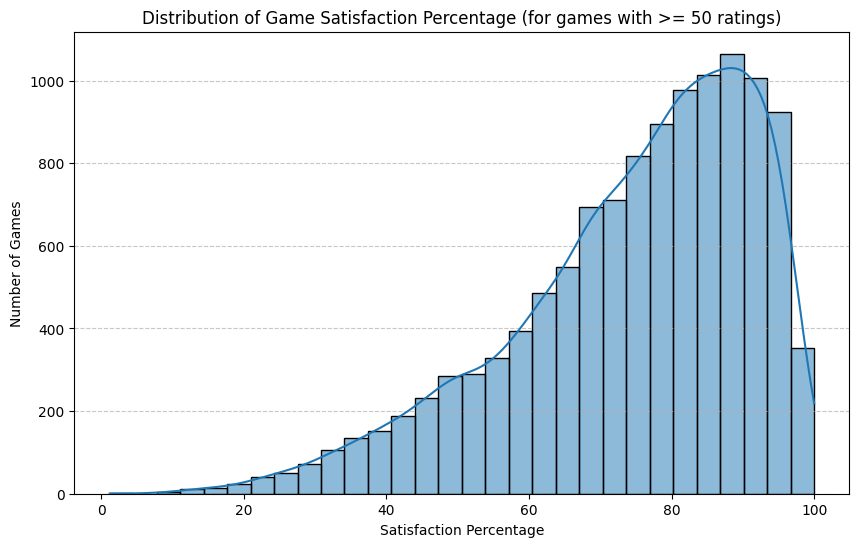

In [29]:
# 4. Creates a histogram showing the distribution of 'satisfaction_pct'
#    (only for games with at least 50 total_ratings)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df[df['total_ratings'] >= 50]['satisfaction_pct'].dropna(), bins=30, kde=True)
plt.title('Distribution of Game Satisfaction Percentage (for games with >= 50 ratings)')
plt.xlabel('Satisfaction Percentage')
plt.ylabel('Number of Games')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Playtime and Achievement Analysis

In [30]:
# 1. Shows the TOP 15 games by 'average_playtime' as a table
print("\n--- Top 15 Games by Average Playtime ---")
top_playtime_games = df.sort_values(by='average_playtime', ascending=False).head(15)
display(top_playtime_games[['name', 'average_playtime', 'median_playtime']])


--- Top 15 Games by Average Playtime ---


,name,average_playtime,median_playtime
9201,The Abbey of Crime Extensum,190625,190625
1478,The Banner Saga: Factions,95245,190489
6014,The Secret of Tremendous Corporation,95242,190445
8969,PRICE,63481,63490
3930,Boundless,55204,55204
3969,Shroud of the Avatar: Forsaken Virtues,54618,54618
2435,X-Plane 11,44169,44169
23409,懒人修仙传,43632,71857
2023,Fantasy Grounds,43074,86148
8919,Screeps,38805,38805


/tmp/ipykernel_1414/1877448076.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_free', y='average_playtime', palette='Pastel1')


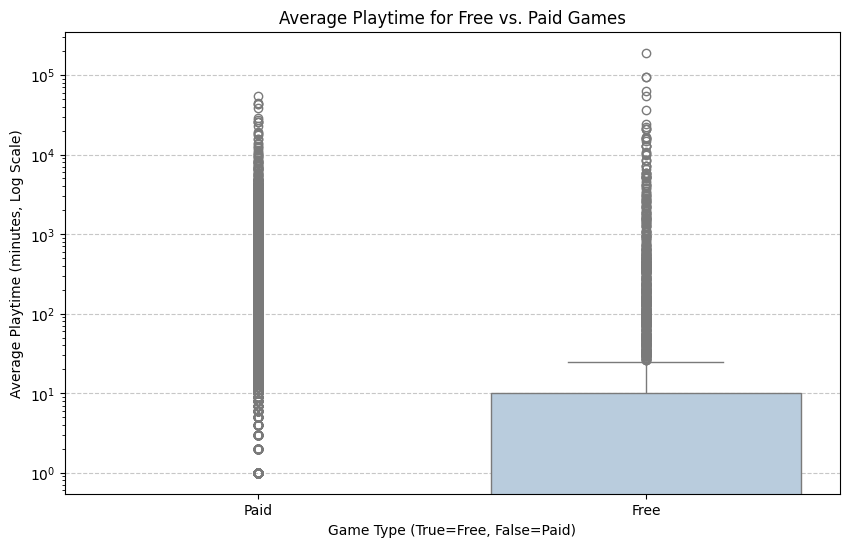

In [31]:
# 2. Creates a box plot comparing 'average_playtime' between Free games (is_free=True) and Paid games (is_free=False)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_free', y='average_playtime', palette='Pastel1')
plt.yscale('log') # Use log scale for better readability due to potential outliers
plt.title('Average Playtime for Free vs. Paid Games')
plt.xlabel('Game Type (True=Free, False=Paid)')
plt.ylabel('Average Playtime (minutes, Log Scale)')
plt.xticks([0, 1], ['Paid', 'Free']) # Customize x-axis labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

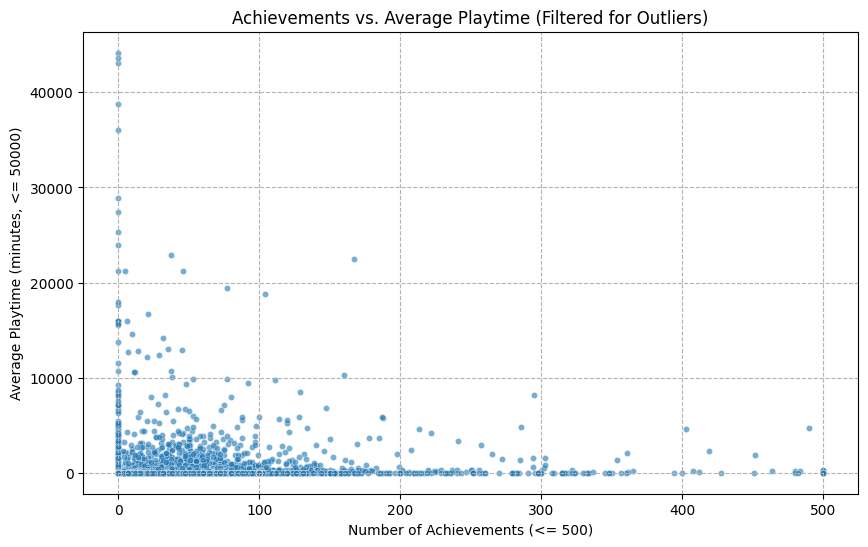

In [32]:
# 3. Creates a scatter plot of 'achievements' (x-axis) vs 'average_playtime' (y-axis)
# Filtering out extreme outliers (games with more than 500 achievements or more than 50000 average_playtime)

filtered_df_achievements = df[
    (df['achievements'] <= 500) &
    (df['average_playtime'] <= 50000)
].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=filtered_df_achievements, x='achievements', y='average_playtime', alpha=0.6, s=20)
plt.title('Achievements vs. Average Playtime (Filtered for Outliers)')
plt.xlabel('Number of Achievements (<= 500)')
plt.ylabel('Average Playtime (minutes, <= 50000)')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

In [33]:
# 4. Calculates and prints the correlation coefficient between 'achievements' and 'average_playtime'
correlation = df['achievements'].corr(df['average_playtime'])
print(f"\nCorrelation between 'achievements' and 'average_playtime': {correlation:.2f}")


Correlation between 'achievements' and 'average_playtime': 0.01


### Developer and Publisher Analysis

/tmp/ipykernel_1414/51366508.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=developer_counts.index, y=developer_counts.values, palette='viridis')


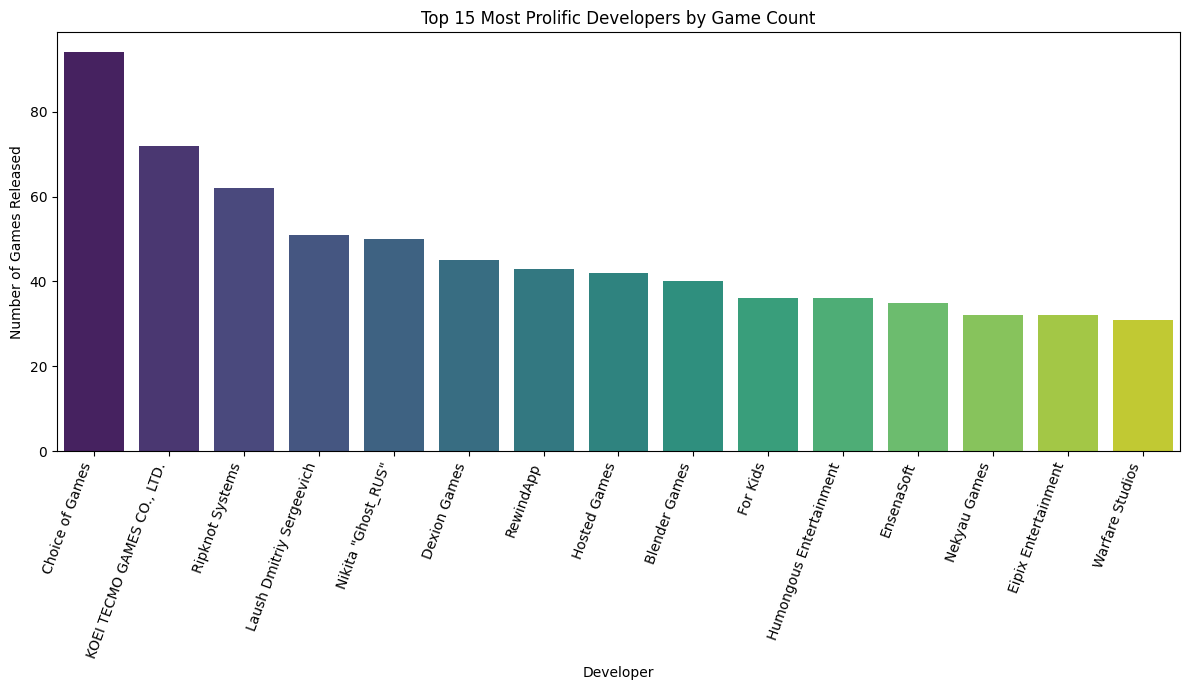

In [34]:
# 1. Groups by 'developer', counts how many games each developer has released,
#    and shows the TOP 15 most prolific developers as a bar chart

plt.figure(figsize=(12, 7))
developer_counts = df['developer'].value_counts().head(15)
sns.barplot(x=developer_counts.index, y=developer_counts.values, palette='viridis')
plt.title('Top 15 Most Prolific Developers by Game Count')
plt.xlabel('Developer')
plt.ylabel('Number of Games Released')
plt.xticks(rotation=70, ha='right')
plt.tight_layout()
plt.show()

In [35]:
# 2. Among developers with AT LEAST 5 games, calculates their average 'satisfaction_pct'
#    and shows the TOP 10 highest-rated developers as a table

print("\n--- Top 10 Highest-Rated Developers (with at least 5 games) ---")
developer_stats = df.groupby('developer').agg(
    game_count=('name', 'count'),
    avg_satisfaction=('satisfaction_pct', 'mean')
).round(2)

# Filter for developers with at least 5 games and sort by average satisfaction
high_rated_developers = developer_stats[developer_stats['game_count'] >= 5].sort_values(
    by='avg_satisfaction', ascending=False
).head(10)

display(high_rated_developers)


--- Top 10 Highest-Rated Developers (with at least 5 games) ---


,game_count,avg_satisfaction
developer,,
Blam! Games,5,100.00
EleFun Games,9,97.78
VisualArts/Key,7,96.73
Nickervision Studios,8,96.65
Crankage Games,5,96.26
Fallen Tree Games Ltd,6,96.25
NEKO WORKs,6,95.84
07th Expansion,9,95.80
Andy Jurko,14,95.51


/tmp/ipykernel_1414/1100233141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_reach.index, y=publisher_reach.values, palette='magma')


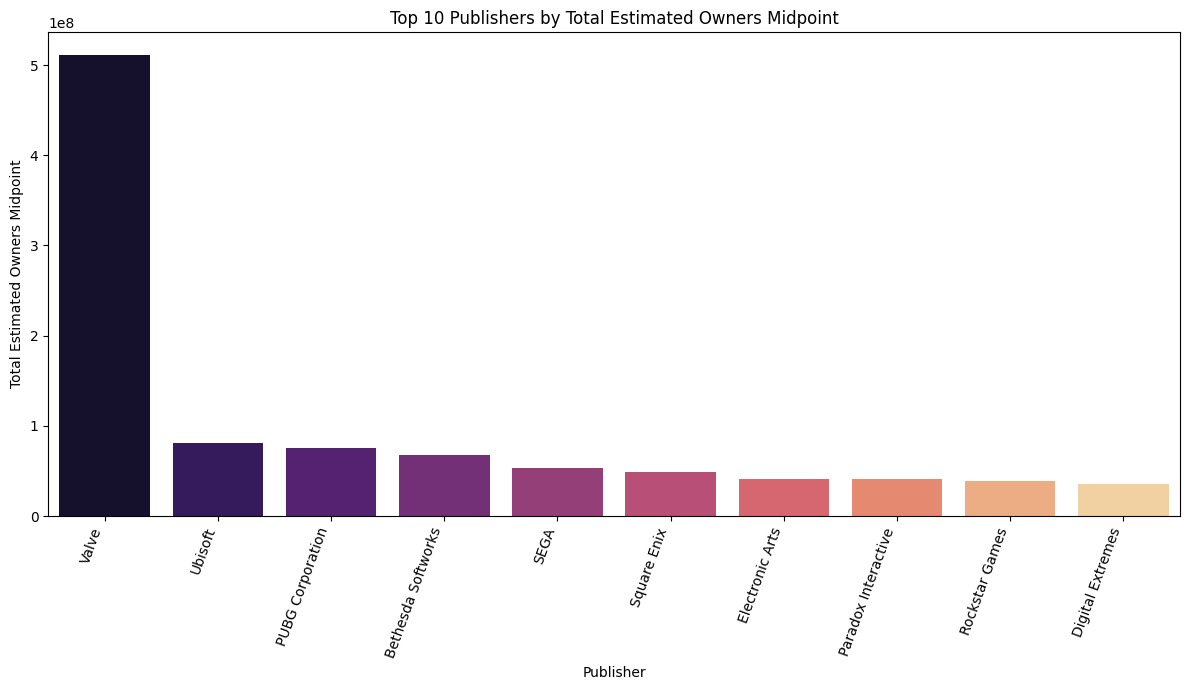

In [36]:
# 3. Groups by 'publisher' and shows the TOP 10 publishers by total 'owners_midpoint'
#    summed across all their games (i.e. total estimated reach) as a bar chart

plt.figure(figsize=(12, 7))
publisher_reach = df.groupby('publisher')['owners_midpoint'].sum().nlargest(10)
sns.barplot(x=publisher_reach.index, y=publisher_reach.values, palette='magma')
plt.title('Top 10 Publishers by Total Estimated Owners Midpoint')
plt.xlabel('Publisher')
plt.ylabel('Total Estimated Owners Midpoint')
plt.xticks(rotation=70, ha='right')
plt.tight_layout()
plt.show()

### Time-Series Analysis: Release Trends and Pricing

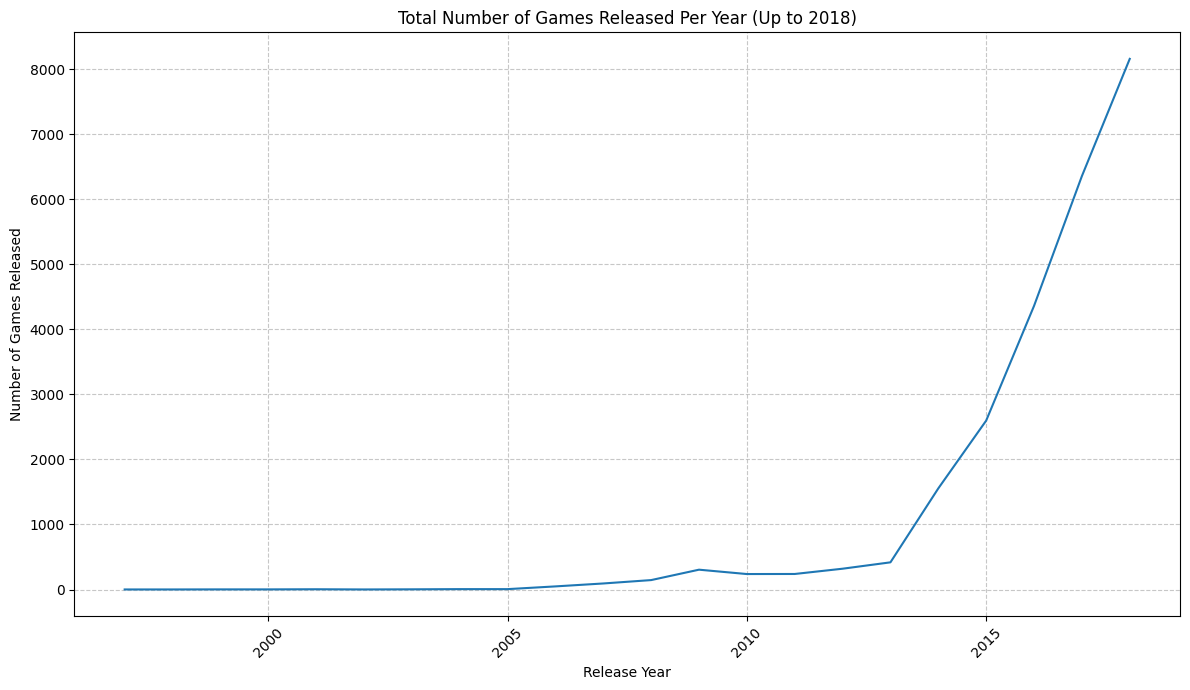

In [37]:
# 1. Creates a line chart showing the total NUMBER OF GAMES RELEASED per 'release_year'
#    from the earliest year to 2018

plt.figure(figsize=(12, 7))
games_per_year = df[df['release_year'] <= 2018]['release_year'].value_counts().sort_index()
sns.lineplot(x=games_per_year.index, y=games_per_year.values)
plt.title('Total Number of Games Released Per Year (Up to 2018)')
plt.xlabel('Release Year')
plt.ylabel('Number of Games Released')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

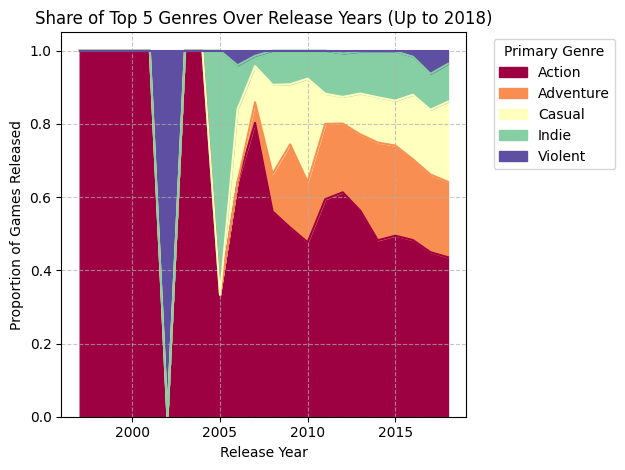

In [38]:
# 2. Creates a stacked area chart showing how the top 5 genres' share of releases has changed over release_year

# Get top 5 genres overall
top_5_genres = df['primary_genre'].value_counts().nlargest(5).index

# Filter data for top 5 genres and years up to 2018
genre_trends_df = df[
    (df['primary_genre'].isin(top_5_genres)) &
    (df['release_year'] <= 2018)
]

# Group by year and genre, then count games
genre_yearly_counts = genre_trends_df.groupby(['release_year', 'primary_genre']).size().unstack(fill_value=0)

# Calculate proportion for stacked area chart
genre_yearly_proportions = genre_yearly_counts.divide(genre_yearly_counts.sum(axis=1), axis=0)

plt.figure(figsize=(15, 8))
genre_yearly_proportions.plot(kind='area', stacked=True, colormap='Spectral')
plt.title('Share of Top 5 Genres Over Release Years (Up to 2018)')
plt.xlabel('Release Year')
plt.ylabel('Proportion of Games Released')
plt.legend(title='Primary Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

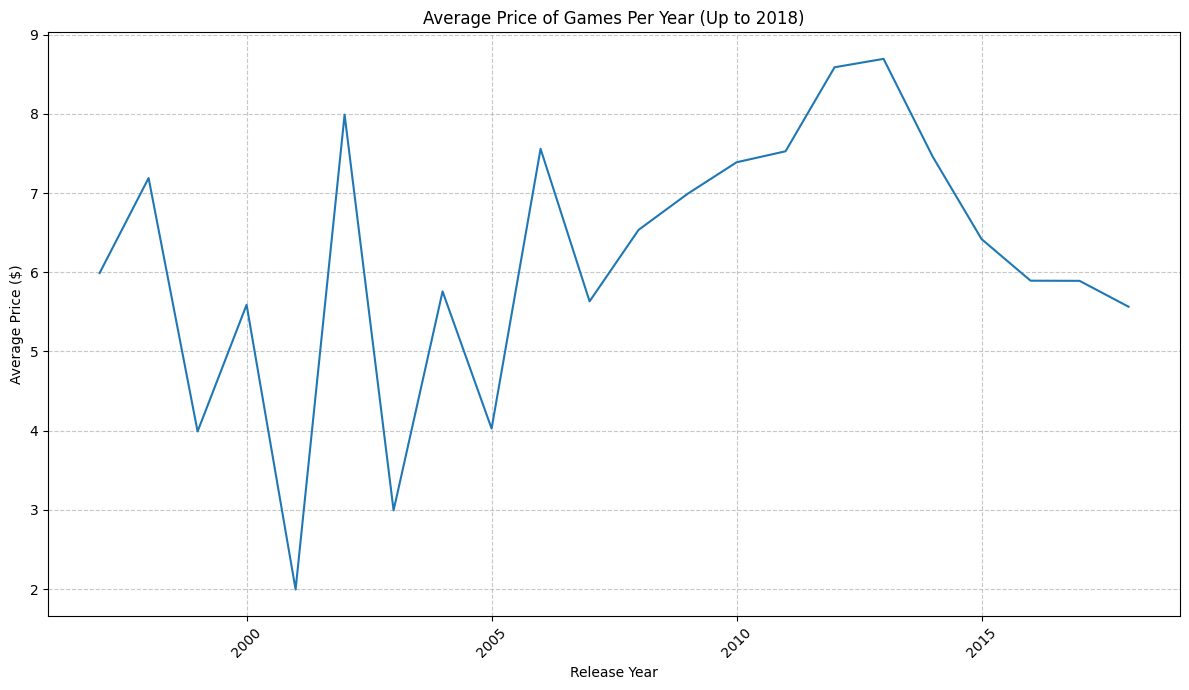

In [39]:
# 3. Creates a line chart showing the average 'price' of games released each year
#    from the earliest year to 2018

plt.figure(figsize=(12, 7))
avg_price_per_year = df[df['release_year'] <= 2018].groupby('release_year')['price'].mean()
sns.lineplot(x=avg_price_per_year.index, y=avg_price_per_year.values)
plt.title('Average Price of Games Per Year (Up to 2018)')
plt.xlabel('Release Year')
plt.ylabel('Average Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Platform and Language Analysis

In [40]:
# 1. Creates a new column 'platform_count' counting how many platforms each game supports
df['platform_count'] = df['platforms'].apply(lambda x: len(x.split(';')))
display(df.head())

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,...,owners,price,release_year,owners_midpoint,total_ratings,satisfaction_pct,is_free,price_category,primary_genre,platform_count
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,10000000-20000000,7.19,2000,15000000.0,127873,97.39,False,Mid-range,Action,3
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,5000000-10000000,3.99,1999,7500000.0,3951,83.98,False,Budget,Action,3
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,...,5000000-10000000,3.99,2003,7500000.0,3814,89.56,False,Budget,Action,3
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,5000000-10000000,3.99,2001,7500000.0,1540,82.66,False,Budget,Action,3
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,...,5000000-10000000,3.99,1999,7500000.0,5538,94.80,False,Budget,Action,3


/tmp/ipykernel_1414/2532187967.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='platform_count', palette='viridis')


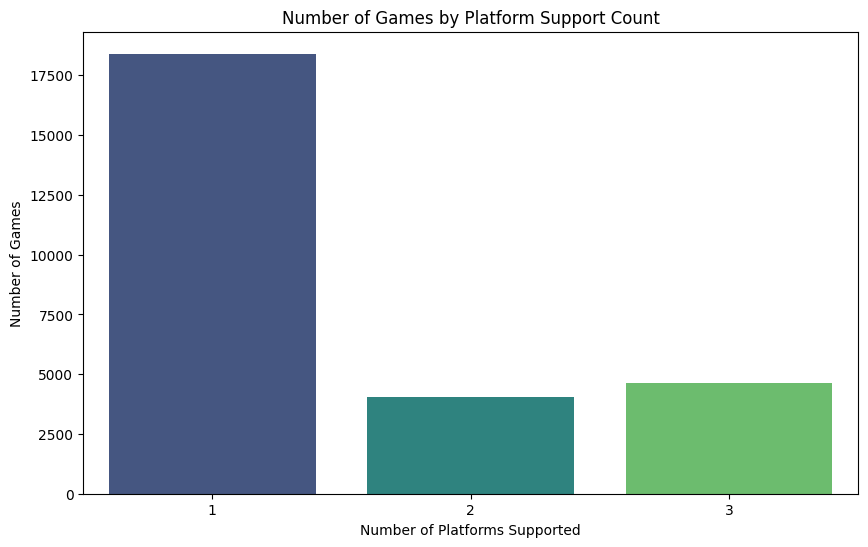

In [41]:
# 2. Creates a bar chart showing how many games support 1, 2, or 3 platforms
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='platform_count', palette='viridis')
plt.title('Number of Games by Platform Support Count')
plt.xlabel('Number of Platforms Supported')
plt.ylabel('Number of Games')
plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_1414/1753517598.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_owners_by_platform_type, x='multi_platform', y='owners_midpoint', palette='magma')


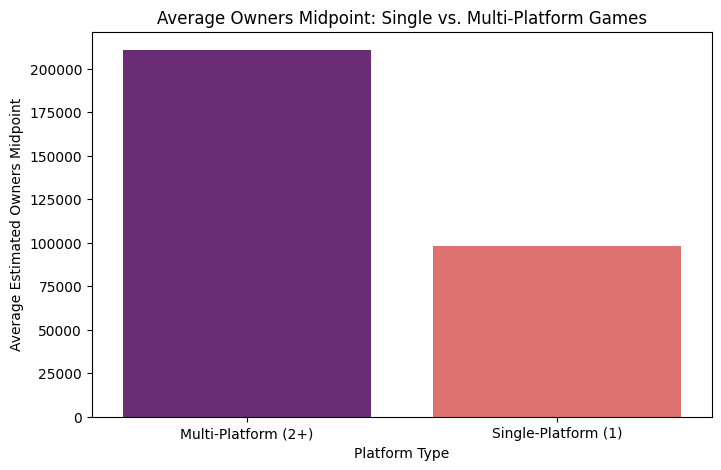

In [42]:
# 3. Compares average 'owners_midpoint' between games with 1 platform vs multi-platform
#    (2 or more) games, shown as a bar chart

df['multi_platform'] = df['platform_count'].apply(lambda x: 'Multi-Platform (2+)' if x > 1 else 'Single-Platform (1)')

avg_owners_by_platform_type = df.groupby('multi_platform')['owners_midpoint'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_owners_by_platform_type, x='multi_platform', y='owners_midpoint', palette='magma')
plt.title('Average Owners Midpoint: Single vs. Multi-Platform Games')
plt.xlabel('Platform Type')
plt.ylabel('Average Estimated Owners Midpoint')
plt.show()

/tmp/ipykernel_1414/2544525214.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_satisfaction_by_language, x='english', y='satisfaction_pct', palette='coolwarm')


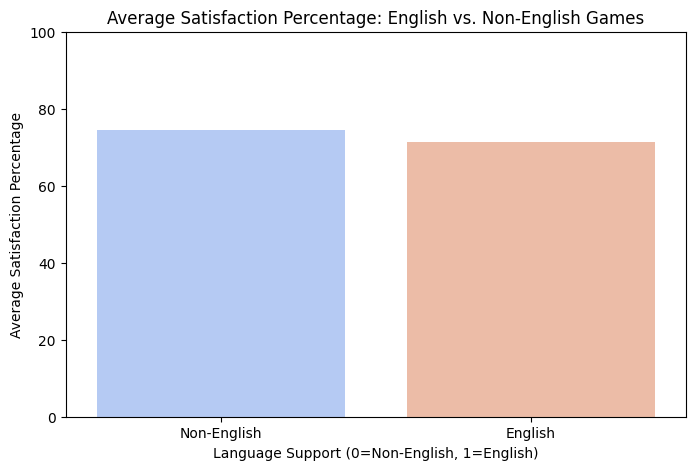

In [43]:
# 4. Compares average 'satisfaction_pct' between English-supported games (english=1) and
#    non-English games (english=0), shown as a bar chart

avg_satisfaction_by_language = df.groupby('english')['satisfaction_pct'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_satisfaction_by_language, x='english', y='satisfaction_pct', palette='coolwarm')
plt.title('Average Satisfaction Percentage: English vs. Non-English Games')
plt.xlabel('Language Support (0=Non-English, 1=English)')
plt.ylabel('Average Satisfaction Percentage')
plt.xticks([0, 1], ['Non-English', 'English'])
plt.ylim(0, 100) # Ensure y-axis is within percentage range
plt.show()

# 5. Prints a one-line summary interpreting whether multi-platform support seems associated
#    with a larger player base in this data

Based on the data, multi-platform games (supporting 2 or more platforms) appear to have a larger average estimated player base ('owners_midpoint') compared to single-platform games.

### Hidden Gems Analysis

In [44]:
# Calculate the median of 'owners_midpoint' to define the bottom 50%
owners_midpoint_median = df['owners_midpoint'].median()

# 1. Filters the dataframe to find all games matching the criteria
hidden_gems_df = df[
    (df['satisfaction_pct'] >= 90) &
    (df['total_ratings'] >= 100) &
    (df['total_ratings'] <= 2000) &
    (df['owners_midpoint'] <= owners_midpoint_median)
].copy()

# 2. Sorts them by satisfaction_pct descending
hidden_gems_df = hidden_gems_df.sort_values(by='satisfaction_pct', ascending=False)

# 3. Displays the TOP 20 hidden gems as a table
print("\n--- Top 20 Hidden Gems ---")
display(hidden_gems_df.head(20)[['name', 'satisfaction_pct', 'total_ratings', 'owners_midpoint', 'price']])

# 4. Prints a summary sentence
total_games = len(df)
num_hidden_gems = len(hidden_gems_df)
print(f"\nSummary: Found {num_hidden_gems} hidden gems out of {total_games} total games in the dataset.")


--- Top 20 Hidden Gems ---


,name,satisfaction_pct,total_ratings,owners_midpoint,price
25913,祈風 Inorikaze,100.00,114,10000.0,8.29
8548,Champions of Breakfast,100.00,112,10000.0,2.09
23296,Sabbat of the Witch,99.62,523,10000.0,23.79
13937,Don't Escape: 4 Days in a Wasteland,99.48,193,10000.0,10.99
22281,Flowers -Le volume sur ete-,99.45,183,10000.0,15.49
23545,Lucah: Born of a Dream,99.38,160,10000.0,15.49
24596,東方紺珠伝 ～ Legacy of Lunatic Kingdom.,99.34,152,10000.0,11.39
26780,Shipped,99.33,298,10000.0,5.20
23867,Arcade Spirits,99.28,138,10000.0,15.49
25642,Kaori After Story,99.22,257,10000.0,7.19



Summary: Found 513 hidden gems out of 27075 total games in the dataset.


### Summary Dashboard of Key Insights

/tmp/ipykernel_1414/981190926.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis', ax=axes[0, 0])
/tmp/ipykernel_1414/981190926.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='price_category', y='satisfaction_pct', order=price_category_order, palette='coolwarm', showfliers=False, ax=axes[1, 0])


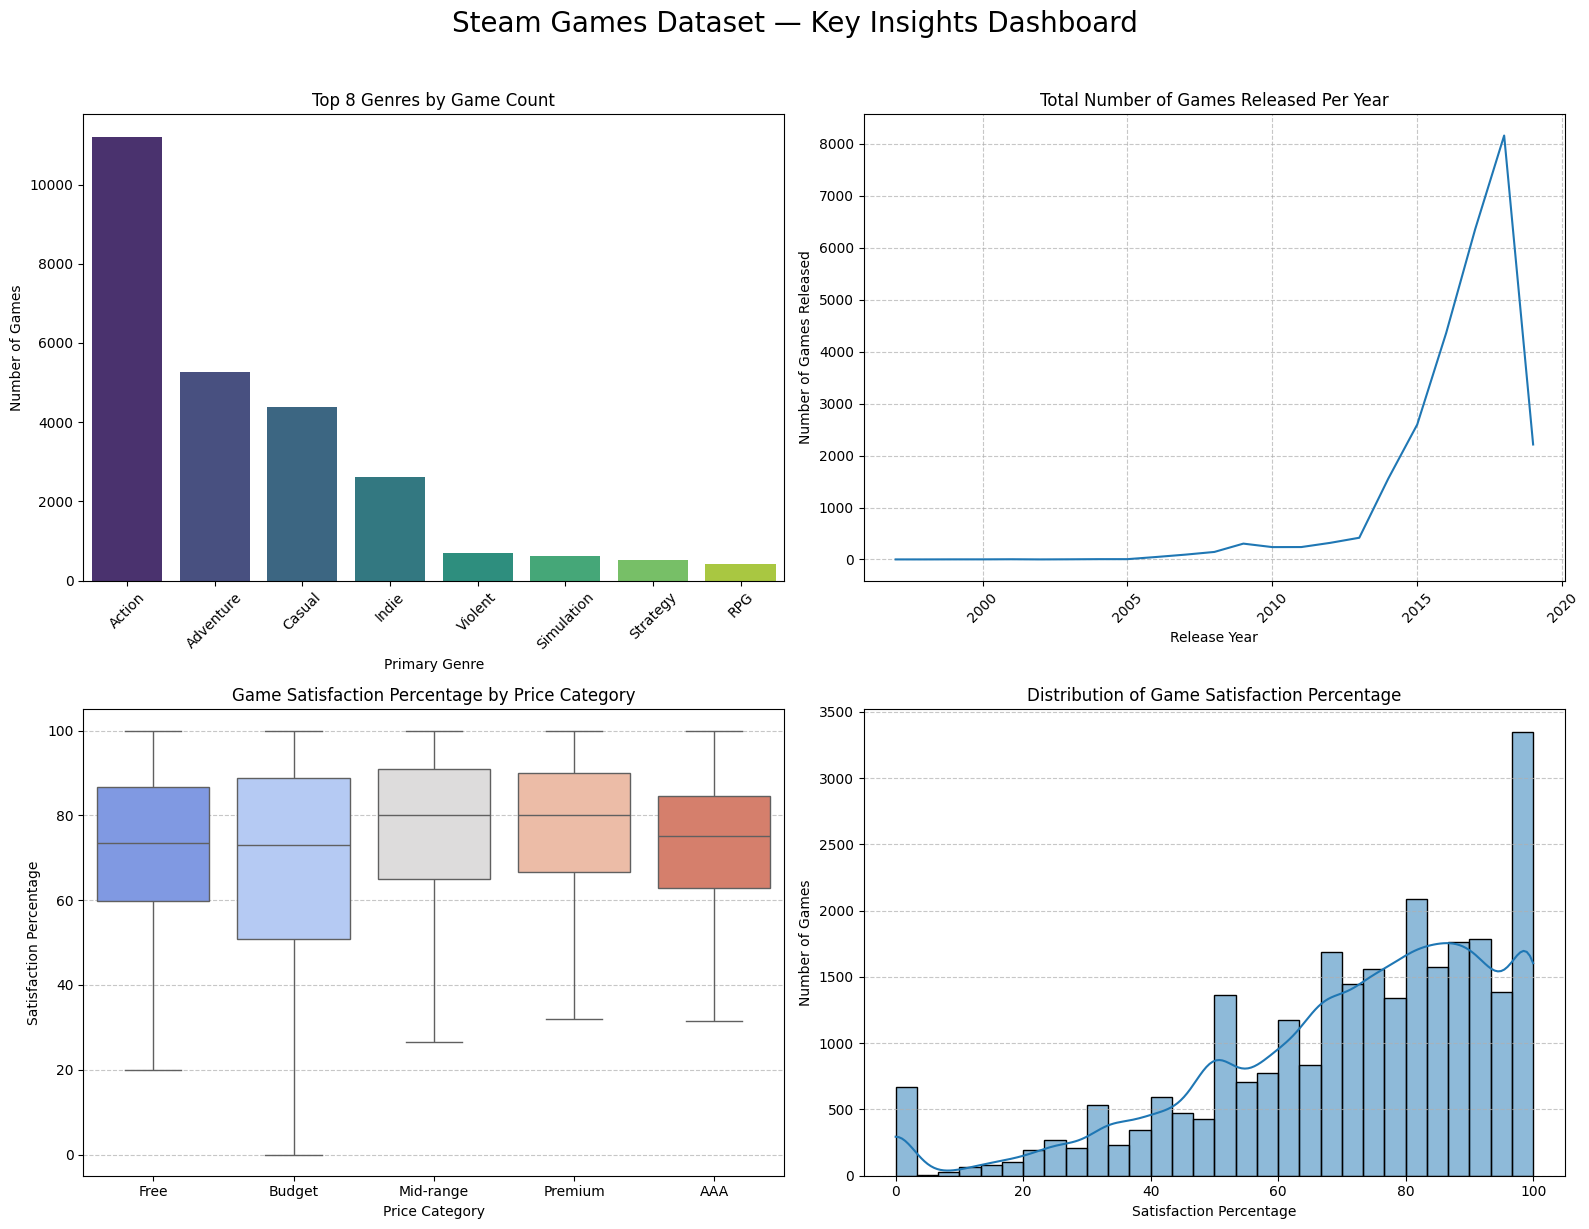

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 4 subplots arranged in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top-left: Bar chart of top 8 genres by game count
genre_counts = df['primary_genre'].value_counts().head(8)
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Top 8 Genres by Game Count')
axes[0, 0].set_xlabel('Primary Genre')
axes[0, 0].set_ylabel('Number of Games')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Top-right: Line chart of games released per year
games_per_year_all = df['release_year'].value_counts().sort_index()
sns.lineplot(x=games_per_year_all.index, y=games_per_year_all.values, ax=axes[0, 1])
axes[0, 1].set_title('Total Number of Games Released Per Year')
axes[0, 1].set_xlabel('Release Year')
axes[0, 1].set_ylabel('Number of Games Released')
axes[0, 1].grid(True, linestyle='--', alpha=0.7)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Bottom-left: Box plot of satisfaction_pct by price_category
price_category_order = ['Free', 'Budget', 'Mid-range', 'Premium', 'AAA']
sns.boxplot(data=df, x='price_category', y='satisfaction_pct', order=price_category_order, palette='coolwarm', showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title('Game Satisfaction Percentage by Price Category')
axes[1, 0].set_xlabel('Price Category')
axes[1, 0].set_ylabel('Satisfaction Percentage')
axes[1, 0].set_ylim(-5, 105)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# 4. Bottom-right: Histogram of satisfaction_pct distribution across all games
sns.histplot(df['satisfaction_pct'].dropna(), bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Game Satisfaction Percentage')
axes[1, 1].set_xlabel('Satisfaction Percentage')
axes[1, 1].set_ylabel('Number of Games')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Overall figure title and tight layout
plt.suptitle('Steam Games Dataset — Key Insights Dashboard', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()